# AG3 - Actividad Guiada 3

**Asignatura:** Algoritmos de Optimización  
**Nombre:** Mario Martínez Romero  
**URL a la carpeta AG3 de GitHub:** `https://github.com/marmarrom9993/Algoritmos-de-optimizaci-n/tree/main/AG3`

## Problema del Agente Viajero y metaheurísticas

En este cuaderno se trabaja con el problema del agente viajero (*Traveling Salesman Problem*, TSP) usando la instancia `swiss42` de TSPLIB.

La actividad desarrolla los métodos principales de la AG3:

1. Carga de datos del problema TSP.
2. Generación y evaluación de soluciones.
3. Búsqueda aleatoria.
4. Búsqueda local.
5. Recocido simulado.
6. Comparación de resultados.

Además, se añaden los dos retos de mejora:

1. **Búsqueda local con entornos variables.**
2. **Recocido simulado con una elección de vecina menos aleatoria.**


## 1. Importación de librerías

Se utilizan librerías básicas de Python. No se usa una librería externa de optimización, porque el objetivo de la actividad es implementar los algoritmos y entender su funcionamiento.

In [1]:
import os
import re
import gzip
import math
import random
import urllib.request
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

## 2. Carga de la instancia `swiss42`

La instancia `swiss42` tiene 42 nodos. Como en el material de la actividad, se supone que se empieza y termina en el nodo 0.

El óptimo conocido para esta instancia es **1273**, por lo que se puede usar como referencia para valorar la calidad de las soluciones encontradas.

In [2]:
def descargar_swiss42(nombre_fichero="swiss42.tsp"):
    """
    Descarga la instancia swiss42.tsp si no está ya en el entorno.
    Se prueban varias rutas porque algunas URLs antiguas pueden fallar.
    """
    if os.path.exists(nombre_fichero):
        print(f"El fichero {nombre_fichero} ya existe en el entorno.")
        return nombre_fichero

    urls_texto = [
        "https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp",
        "https://raw.githubusercontent.com/mastqe/tsplib/master/swiss42.tsp"
    ]

    urls_gz = [
        "http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz"
    ]

    # Intento con fichero de texto
    for url in urls_texto:
        try:
            print("Intentando descargar:", url)
            urllib.request.urlretrieve(url, nombre_fichero)
            print("Descarga realizada correctamente.")
            return nombre_fichero
        except Exception as e:
            print("No se pudo descargar desde esa URL:", e)

    # Intento con fichero comprimido .gz
    for url in urls_gz:
        try:
            print("Intentando descargar comprimido:", url)
            gz_file = nombre_fichero + ".gz"
            urllib.request.urlretrieve(url, gz_file)
            with gzip.open(gz_file, "rb") as f_in:
                with open(nombre_fichero, "wb") as f_out:
                    f_out.write(f_in.read())
            print("Descarga y descompresión realizadas correctamente.")
            return nombre_fichero
        except Exception as e:
            print("No se pudo descargar desde esa URL:", e)

    raise FileNotFoundError(
        "No se ha podido descargar swiss42.tsp. "
        "Sube manualmente el archivo swiss42.tsp al entorno o revisa la conexión a Internet."
    )


def leer_matriz_tsplib_full_matrix(nombre_fichero):
    """
    Lee una instancia TSPLIB con EDGE_WEIGHT_FORMAT: FULL_MATRIX.
    Devuelve el nombre del problema y la matriz de distancias.
    """
    with open(nombre_fichero, "r", encoding="utf-8", errors="ignore") as f:
        texto = f.read()

    nombre = re.search(r"NAME\s*:?\s*([^\s]+)", texto)
    nombre = nombre.group(1) if nombre else "problema_tsp"

    dimension = re.search(r"DIMENSION\s*:?\s*(\d+)", texto)
    if not dimension:
        raise ValueError("No se ha encontrado DIMENSION en el fichero TSPLIB.")
    dimension = int(dimension.group(1))

    if "EDGE_WEIGHT_SECTION" not in texto:
        raise ValueError("No se ha encontrado EDGE_WEIGHT_SECTION en el fichero TSPLIB.")

    seccion = texto.split("EDGE_WEIGHT_SECTION", 1)[1]
    seccion = seccion.split("EOF", 1)[0]
    numeros = [int(x) for x in re.findall(r"-?\d+", seccion)]

    if len(numeros) != dimension * dimension:
        raise ValueError(
            f"La matriz no tiene el tamaño esperado. "
            f"Esperado: {dimension * dimension}, encontrado: {len(numeros)}"
        )

    matriz = np.array(numeros).reshape((dimension, dimension))
    return nombre, matriz


@dataclass
class ProblemaTSP:
    name: str
    matriz: np.ndarray

    def get_nodes(self):
        return list(range(self.matriz.shape[0]))

    def get_edges(self):
        n = self.matriz.shape[0]
        return [(i, j) for i in range(n) for j in range(n)]

    def get_weight(self, a, b):
        return int(self.matriz[a, b])


file = descargar_swiss42()
nombre, matriz_distancias = leer_matriz_tsplib_full_matrix(file)
problem = ProblemaTSP(nombre, matriz_distancias)

Nodos = problem.get_nodes()
Aristas = problem.get_edges()
OPTIMO_CONOCIDO = 1273

print("Nombre del problema:", problem.name)
print("Número de nodos:", len(Nodos))
print("Distancia entre 0 y 1:", problem.get_weight(0, 1))
print("Óptimo conocido:", OPTIMO_CONOCIDO)

El fichero swiss42.tsp ya existe en el entorno.
Nombre del problema: swiss42
Número de nodos: 42
Distancia entre 0 y 1: 15
Óptimo conocido: 1273


In [3]:
# Número teórico de rutas distintas en un TSP simétrico, fijando el nodo de inicio.
# Para n ciudades: (n-1)! / 2
n = len(Nodos)
total_soluciones = math.factorial(n - 1) // 2
print("Número aproximado de soluciones factibles:")
print(total_soluciones)

Número aproximado de soluciones factibles:
16726263306581903554085031026720375832576000000000


## 3. Funciones básicas

Estas funciones son la base de todos los algoritmos posteriores.

- `crear_solucion`: genera una ruta aleatoria empezando por el nodo 0.
- `distancia`: obtiene la distancia entre dos nodos.
- `distancia_total`: calcula la distancia total de una ruta, incluyendo la vuelta al nodo inicial.
- `es_solucion_valida`: comprueba que una solución visita todos los nodos una sola vez.

In [4]:
def crear_solucion(Nodos):
    """Genera una solución aleatoria empezando siempre en el nodo 0."""
    solucion = [Nodos[0]]
    restantes = list(Nodos[1:])
    random.shuffle(restantes)
    return solucion + restantes


def distancia(a, b, problem):
    """Devuelve la distancia entre dos nodos."""
    return problem.get_weight(a, b)


def distancia_total(solucion, problem):
    """Calcula la distancia total de la ruta, incluyendo la vuelta al nodo inicial."""
    total = 0
    for i in range(len(solucion) - 1):
        total += distancia(solucion[i], solucion[i + 1], problem)
    total += distancia(solucion[-1], solucion[0], problem)
    return total


def es_solucion_valida(solucion, Nodos):
    """Comprueba que la solución contiene todos los nodos una sola vez."""
    return len(solucion) == len(Nodos) and set(solucion) == set(Nodos) and solucion[0] == Nodos[0]


solucion_prueba = crear_solucion(Nodos)
print("Solución de prueba válida:", es_solucion_valida(solucion_prueba, Nodos))
print("Distancia de prueba:", distancia_total(solucion_prueba, problem))
print("Primeros nodos de la solución:", solucion_prueba[:10])

Solución de prueba válida: True
Distancia de prueba: 4543
Primeros nodos de la solución: [0, 10, 4, 11, 37, 26, 25, 31, 12, 5]


## 4. Búsqueda aleatoria

La búsqueda aleatoria genera muchas soluciones al azar y se queda con la mejor encontrada.

No garantiza encontrar el óptimo, pero sirve como punto de comparación frente a métodos más elaborados.

In [5]:
def busqueda_aleatoria(problem, N=5000):
    """
    Genera N soluciones aleatorias y devuelve la mejor.
    """
    Nodos = problem.get_nodes()
    mejor_solucion = None
    mejor_distancia = float("inf")

    for _ in range(N):
        solucion = crear_solucion(Nodos)
        d = distancia_total(solucion, problem)
        if d < mejor_distancia:
            mejor_solucion = solucion
            mejor_distancia = d

    return mejor_solucion, mejor_distancia


random.seed(42)
sol_random, dist_random = busqueda_aleatoria(problem, N=5000)
print("Mejor solución por búsqueda aleatoria:", sol_random)
print("Distancia:", dist_random)
print("Diferencia respecto al óptimo conocido:", dist_random - OPTIMO_CONOCIDO)

Mejor solución por búsqueda aleatoria: [0, 26, 27, 14, 36, 16, 17, 31, 38, 29, 24, 20, 33, 35, 7, 5, 6, 25, 9, 30, 22, 40, 34, 28, 41, 10, 12, 18, 11, 13, 32, 15, 8, 23, 19, 37, 1, 21, 4, 2, 3, 39]
Distancia: 3703
Diferencia respecto al óptimo conocido: 2430


## 5. Búsqueda local básica

La búsqueda local parte de una solución inicial y trata de mejorarla buscando soluciones vecinas.

En la versión básica se usa un único operador de vecindad: **intercambiar dos nodos**. Este enfoque puede mejorar mucho una solución aleatoria, pero también puede quedarse atrapado en un mínimo local.

In [6]:
def aplicar_operador(solucion, i, j, operador):
    """
    Aplica un operador de vecindad sobre la solución.
    El nodo 0 no se mueve, porque se fija como punto de salida.
    """
    nueva = solucion.copy()

    if operador == "swap":
        # Intercambia dos nodos.
        nueva[i], nueva[j] = nueva[j], nueva[i]

    elif operador == "inversion":
        # Invierte una sublista entre i y j.
        nueva = solucion[:i] + list(reversed(solucion[i:j+1])) + solucion[j+1:]

    elif operador == "insercion":
        # Extrae el nodo de la posición i y lo inserta en la posición j.
        ciudad = nueva.pop(i)
        nueva.insert(j, ciudad)

    else:
        raise ValueError("Operador no reconocido")

    return nueva


def mejor_vecino(solucion, problem, operador="swap"):
    """
    Recorre todos los vecinos generados por un operador y devuelve el mejor.
    """
    mejor = solucion.copy()
    mejor_distancia = distancia_total(solucion, problem)

    for i in range(1, len(solucion) - 1):
        for j in range(i + 1, len(solucion)):
            vecino = aplicar_operador(solucion, i, j, operador)
            d = distancia_total(vecino, problem)
            if d < mejor_distancia:
                mejor = vecino
                mejor_distancia = d

    return mejor, mejor_distancia


def busqueda_local_basica(problem, solucion_inicial=None, max_iter=100):
    """
    Búsqueda local usando solo el operador swap.
    Se detiene cuando ya no encuentra mejora o cuando alcanza max_iter.
    """
    Nodos = problem.get_nodes()
    solucion = solucion_inicial if solucion_inicial is not None else crear_solucion(Nodos)
    distancia_actual = distancia_total(solucion, problem)

    historial = []

    for iteracion in range(1, max_iter + 1):
        vecino, distancia_vecino = mejor_vecino(solucion, problem, operador="swap")

        historial.append({
            "iteracion": iteracion,
            "distancia": distancia_actual
        })

        if distancia_vecino < distancia_actual:
            solucion = vecino
            distancia_actual = distancia_vecino
        else:
            break

    return solucion, distancia_actual, pd.DataFrame(historial)


random.seed(42)
sol_local, dist_local, hist_local = busqueda_local_basica(problem, max_iter=100)
print("Mejor solución por búsqueda local básica:", sol_local)
print("Distancia:", dist_local)
print("Diferencia respecto al óptimo conocido:", dist_local - OPTIMO_CONOCIDO)

Mejor solución por búsqueda local básica: [0, 6, 18, 12, 11, 25, 41, 40, 24, 21, 23, 9, 4, 5, 13, 19, 36, 35, 32, 30, 29, 39, 22, 38, 34, 33, 20, 31, 17, 37, 7, 27, 2, 3, 1, 15, 16, 14, 26, 10, 8, 28]
Distancia: 1887
Diferencia respecto al óptimo conocido: 614


## 6. Reto 1: búsqueda local con entornos variables

El problema de la búsqueda local básica es que utiliza siempre el mismo tipo de movimiento. Si con ese operador ya no puede mejorar, se detiene, aunque podría existir una mejora usando otro tipo de vecindad.

Para resolver el reto, se implementa una búsqueda con **entornos variables**. Se prueban tres operadores:

1. `swap`: intercambiar dos nodos.
2. `inversion`: invertir una sublista.
3. `insercion`: mover un nodo a otra posición.

La idea es sencilla: cuando un entorno mejora la solución, se vuelve a empezar desde el primer entorno. Si un entorno no mejora, se prueba el siguiente.

In [7]:
def busqueda_entornos_variables(problem, n_arranques=10, max_iter=100,
                                entornos=("swap", "inversion", "insercion")):
    """
    Búsqueda local con entornos variables y multiarranque.

    - Se generan varias soluciones iniciales.
    - En cada una se prueban varios operadores de vecindad.
    - Se conserva la mejor solución global encontrada.
    """
    Nodos = problem.get_nodes()

    mejor_global = None
    mejor_distancia_global = float("inf")
    resumen_arranques = []

    for arranque in range(1, n_arranques + 1):
        solucion = crear_solucion(Nodos)
        distancia_actual = distancia_total(solucion, problem)

        k = 0
        iteracion = 0

        while k < len(entornos) and iteracion < max_iter:
            iteracion += 1
            operador = entornos[k]

            vecino, distancia_vecino = mejor_vecino(solucion, problem, operador=operador)

            if distancia_vecino < distancia_actual:
                solucion = vecino
                distancia_actual = distancia_vecino
                k = 0  # Si mejora, volvemos al primer entorno
            else:
                k += 1  # Si no mejora, probamos otro entorno

        resumen_arranques.append({
            "arranque": arranque,
            "distancia_final": distancia_actual,
            "iteraciones": iteracion
        })

        if distancia_actual < mejor_distancia_global:
            mejor_global = solucion
            mejor_distancia_global = distancia_actual

    return mejor_global, mejor_distancia_global, pd.DataFrame(resumen_arranques)


random.seed(42)
sol_vnd, dist_vnd, resumen_vnd = busqueda_entornos_variables(
    problem,
    n_arranques=10,
    max_iter=80
)

print("Mejor solución con entornos variables:", sol_vnd)
print("Distancia:", dist_vnd)
print("Diferencia respecto al óptimo conocido:", dist_vnd - OPTIMO_CONOCIDO)
resumen_vnd

Mejor solución con entornos variables: [0, 1, 6, 4, 3, 2, 27, 28, 29, 30, 38, 22, 39, 24, 40, 21, 9, 23, 41, 8, 10, 25, 11, 12, 18, 26, 5, 13, 19, 14, 16, 15, 37, 7, 17, 31, 36, 35, 20, 33, 34, 32]
Distancia: 1273
Diferencia respecto al óptimo conocido: 0


,arranque,distancia_final,iteraciones
0,1,1373,80
1,2,1344,71
2,3,1364,59
3,4,1371,59
4,5,1273,67
5,6,1377,54
6,7,1379,78
7,8,1331,58
8,9,1339,62
9,10,1352,72


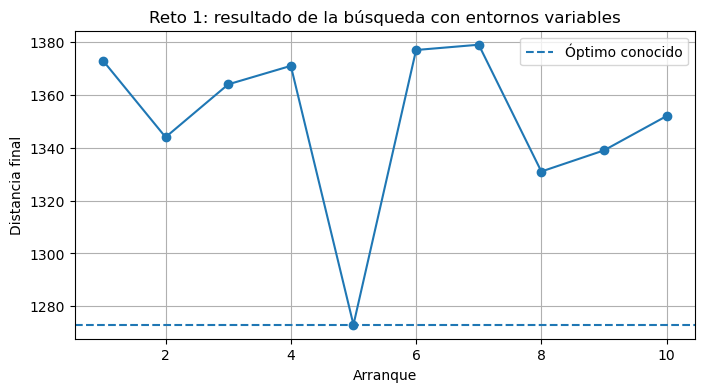

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(resumen_vnd["arranque"], resumen_vnd["distancia_final"], marker="o")
plt.axhline(OPTIMO_CONOCIDO, linestyle="--", label="Óptimo conocido")
plt.title("Reto 1: resultado de la búsqueda con entornos variables")
plt.xlabel("Arranque")
plt.ylabel("Distancia final")
plt.legend()
plt.grid(True)
plt.show()

### Comentario del Reto 1

La mejora consiste en no depender de un único operador de vecindad. Si solo se intercambian dos nodos, el algoritmo puede llegar a una solución que no mejora con ese movimiento, pero que sí podría mejorar si se invierte una sublista o se inserta una ciudad en otra posición.

Además, el multiarranque ayuda porque se repite la búsqueda desde varias soluciones iniciales distintas. Esto no garantiza encontrar el óptimo global, pero aumenta la posibilidad de obtener una buena solución.

## 7. Recocido simulado básico

El recocido simulado también trabaja con soluciones vecinas, pero añade una diferencia importante: puede aceptar soluciones peores con cierta probabilidad.

Al principio, cuando la temperatura es alta, es más fácil aceptar una solución peor. Esto ayuda a escapar de mínimos locales. A medida que la temperatura baja, el algoritmo se vuelve más exigente.

In [9]:
def genera_vecina_aleatorio(solucion):
    """
    Genera una vecina de forma totalmente aleatoria usando swap.
    Esta es la idea básica de la actividad.
    """
    i, j = sorted(random.sample(range(1, len(solucion)), 2))
    return aplicar_operador(solucion, i, j, operador="swap")


def aceptar_solucion(delta, T):
    """
    Criterio de aceptación del recocido simulado.
    Si delta < 0, la solución mejora y se acepta siempre.
    Si delta > 0, empeora y se acepta con probabilidad exp(-delta/T).
    """
    if delta < 0:
        return True
    return random.random() < math.exp(-delta / T)


def recocido_simulado_basico(problem, T0=500, Tmin=0.001, alpha=0.995, max_iter=20000):
    Nodos = problem.get_nodes()
    solucion = crear_solucion(Nodos)
    distancia_actual = distancia_total(solucion, problem)

    mejor_solucion = solucion.copy()
    mejor_distancia = distancia_actual

    T = T0
    historial = []

    for iteracion in range(1, max_iter + 1):
        if T < Tmin:
            break

        vecina = genera_vecina_aleatorio(solucion)
        distancia_vecina = distancia_total(vecina, problem)
        delta = distancia_vecina - distancia_actual

        if aceptar_solucion(delta, T):
            solucion = vecina
            distancia_actual = distancia_vecina

        if distancia_actual < mejor_distancia:
            mejor_solucion = solucion.copy()
            mejor_distancia = distancia_actual

        if iteracion % 100 == 0:
            historial.append({
                "iteracion": iteracion,
                "mejor_distancia": mejor_distancia,
                "temperatura": T
            })

        T *= alpha

    return mejor_solucion, mejor_distancia, pd.DataFrame(historial)


random.seed(42)
sol_sa_basico, dist_sa_basico, hist_sa_basico = recocido_simulado_basico(problem)
print("Mejor solución con recocido simulado básico:", sol_sa_basico)
print("Distancia:", dist_sa_basico)
print("Diferencia respecto al óptimo conocido:", dist_sa_basico - OPTIMO_CONOCIDO)

Mejor solución con recocido simulado básico: [0, 1, 14, 15, 16, 19, 13, 8, 21, 40, 24, 39, 9, 10, 18, 12, 11, 25, 41, 23, 22, 38, 30, 29, 28, 2, 27, 3, 4, 6, 26, 5, 37, 17, 36, 35, 31, 7, 20, 33, 34, 32]
Distancia: 1670
Diferencia respecto al óptimo conocido: 397


## 8. Reto 2: recocido simulado con elección de vecina menos aleatoria

El reto pregunta si se puede mejorar la función `genera_vecina_aleatorio()` con una elección no tan aleatoria.

La mejora aplicada aquí consiste en generar varias vecinas candidatas y quedarse aleatoriamente con una de las mejores. De esta manera:

- sigue existiendo aleatoriedad;
- no siempre se elige la misma vecina;
- se evita que la elección sea completamente ciega;
- se aprovechan varios operadores de vecindad.

In [10]:
def genera_vecina_menos_aleatoria(solucion, problem, n_candidatos=12, top_k=3):
    """
    Genera varias vecinas y elige aleatoriamente una de las mejores.

    Esto mantiene cierta aleatoriedad, pero evita escoger una vecina completamente al azar.
    """
    operadores = ["swap", "inversion", "insercion"]
    candidatos = []

    for _ in range(n_candidatos):
        i, j = sorted(random.sample(range(1, len(solucion)), 2))
        operador = random.choice(operadores)
        vecina = aplicar_operador(solucion, i, j, operador=operador)
        d = distancia_total(vecina, problem)
        candidatos.append((d, vecina, operador))

    candidatos.sort(key=lambda x: x[0])
    mejores = candidatos[:min(top_k, len(candidatos))]

    distancia_elegida, vecina_elegida, operador_elegido = random.choice(mejores)
    return vecina_elegida


def recocido_simulado_mejorado(problem, T0=500, Tmin=0.001, alpha=0.995,
                               max_iter=20000, n_candidatos=12, top_k=3):
    Nodos = problem.get_nodes()
    solucion = crear_solucion(Nodos)
    distancia_actual = distancia_total(solucion, problem)

    mejor_solucion = solucion.copy()
    mejor_distancia = distancia_actual

    T = T0
    historial = []

    for iteracion in range(1, max_iter + 1):
        if T < Tmin:
            break

        vecina = genera_vecina_menos_aleatoria(
            solucion,
            problem,
            n_candidatos=n_candidatos,
            top_k=top_k
        )

        distancia_vecina = distancia_total(vecina, problem)
        delta = distancia_vecina - distancia_actual

        if aceptar_solucion(delta, T):
            solucion = vecina
            distancia_actual = distancia_vecina

        if distancia_actual < mejor_distancia:
            mejor_solucion = solucion.copy()
            mejor_distancia = distancia_actual

        if iteracion % 100 == 0:
            historial.append({
                "iteracion": iteracion,
                "mejor_distancia": mejor_distancia,
                "temperatura": T
            })

        T *= alpha

    return mejor_solucion, mejor_distancia, pd.DataFrame(historial)


random.seed(42)
sol_sa_mejorado, dist_sa_mejorado, hist_sa_mejorado = recocido_simulado_mejorado(problem)
print("Mejor solución con recocido simulado mejorado:", sol_sa_mejorado)
print("Distancia:", dist_sa_mejorado)
print("Diferencia respecto al óptimo conocido:", dist_sa_mejorado - OPTIMO_CONOCIDO)

Mejor solución con recocido simulado mejorado: [0, 3, 4, 18, 12, 11, 25, 10, 8, 41, 23, 9, 40, 24, 21, 39, 22, 38, 30, 29, 28, 2, 27, 32, 34, 33, 20, 35, 36, 31, 17, 7, 37, 15, 16, 14, 19, 13, 5, 26, 6, 1]
Distancia: 1316
Diferencia respecto al óptimo conocido: 43


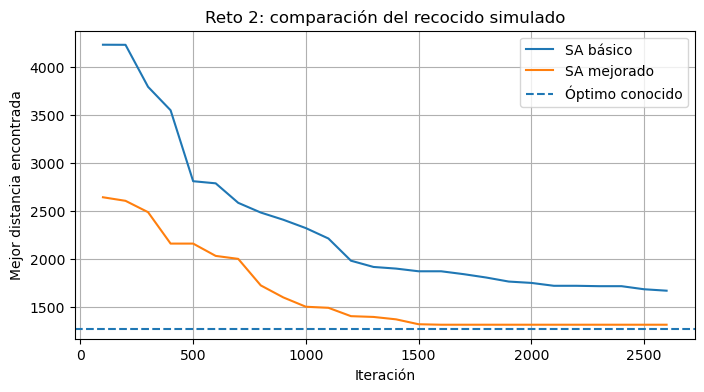

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(hist_sa_basico["iteracion"], hist_sa_basico["mejor_distancia"], label="SA básico")
plt.plot(hist_sa_mejorado["iteracion"], hist_sa_mejorado["mejor_distancia"], label="SA mejorado")
plt.axhline(OPTIMO_CONOCIDO, linestyle="--", label="Óptimo conocido")
plt.title("Reto 2: comparación del recocido simulado")
plt.xlabel("Iteración")
plt.ylabel("Mejor distancia encontrada")
plt.legend()
plt.grid(True)
plt.show()

## 9. Comparación final de resultados

Se comparan los métodos utilizados:

- búsqueda aleatoria;
- búsqueda local básica;
- búsqueda local con entornos variables;
- recocido simulado básico;
- recocido simulado mejorado.

Como el problema es de minimización, cuanto menor sea la distancia, mejor será la solución.

In [12]:
resultados = pd.DataFrame([
    {"metodo": "Búsqueda aleatoria", "distancia": dist_random},
    {"metodo": "Búsqueda local básica", "distancia": dist_local},
    {"metodo": "Entornos variables", "distancia": dist_vnd},
    {"metodo": "SA básico", "distancia": dist_sa_basico},
    {"metodo": "SA mejorado", "distancia": dist_sa_mejorado},
])

resultados["diferencia_optimo"] = resultados["distancia"] - OPTIMO_CONOCIDO
resultados["porcentaje_sobre_optimo"] = (resultados["distancia"] / OPTIMO_CONOCIDO * 100).round(2)
resultados = resultados.sort_values("distancia").reset_index(drop=True)
resultados

,metodo,distancia,diferencia_optimo,porcentaje_sobre_optimo
0,Entornos variables,1273,0,100.00
1,SA mejorado,1316,43,103.38
2,SA básico,1670,397,131.19
3,Búsqueda local básica,1887,614,148.23
4,Búsqueda aleatoria,3703,2430,290.89


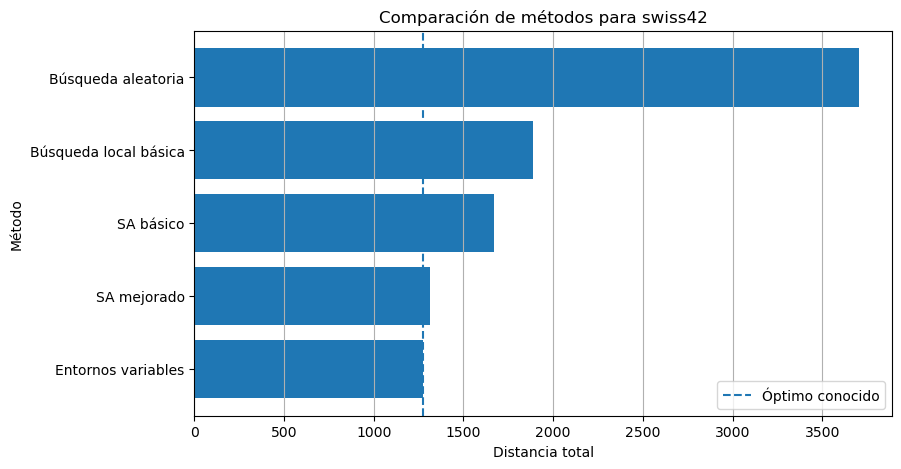

In [13]:
plt.figure(figsize=(9, 5))
plt.barh(resultados["metodo"], resultados["distancia"])
plt.axvline(OPTIMO_CONOCIDO, linestyle="--", label="Óptimo conocido")
plt.title("Comparación de métodos para swiss42")
plt.xlabel("Distancia total")
plt.ylabel("Método")
plt.legend()
plt.grid(axis="x")
plt.show()

## 10. Conclusiones

En esta actividad se ha trabajado el TSP `swiss42` usando diferentes estrategias heurísticas y metaheurísticas.

La **búsqueda aleatoria** sirve como referencia inicial, pero normalmente obtiene soluciones peores porque no aprovecha información de las soluciones ya generadas.

La **búsqueda local básica** mejora una solución inicial mediante vecinos, pero puede quedarse bloqueada en un mínimo local si el operador de vecindad utilizado ya no permite mejorar.

El **primer reto** se ha resuelto incorporando una búsqueda local con **entornos variables**. Esta mejora permite probar varios tipos de movimientos: intercambio de nodos, inversión de sublistas e inserción de nodos. Además, el uso de varios arranques ayuda a explorar regiones distintas del espacio de soluciones.

El **segundo reto** se ha resuelto modificando el recocido simulado para que la generación de vecinas no sea totalmente aleatoria. En lugar de generar una única vecina al azar, se generan varias candidatas y se elige una entre las mejores. Así se mantiene la aleatoriedad, pero la búsqueda queda más orientada hacia soluciones prometedoras.

Ninguno de estos métodos garantiza alcanzar siempre el óptimo global, pero sí permiten encontrar buenas soluciones en un tiempo razonable. Esto encaja con el enfoque de las metaheurísticas: no recorrer todo el espacio de soluciones, sino diseñar procedimientos que permitan aproximarse a soluciones de calidad.

## 11. Resumen de los retos resueltos

| Reto | Mejora implementada | Idea principal |
|---|---|---|
| Búsqueda local con entornos variables | Se usan `swap`, `inversion` e `insercion` | Evitar depender de un único vecindario |
| Recocido simulado mejorado | Se generan varias vecinas y se elige una de las mejores | Reducir la aleatoriedad ciega sin eliminar la exploración |

El notebook queda preparado para subirlo como actividad, añadiendo únicamente el nombre, apellidos y URL del repositorio si se pide en la plataforma.